In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
matches = pd.read_csv("/Users/carlosbolivar/Desktop/Tennis AI Project/data/raw/charting-m-matches.csv")
matches.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Time,Court,Surface,Umpire,Best of,Final TB?,Charted by
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,Jesper De Jong,Michael Zheng,R,R,20260521,Roland Garros,Q3,NaN,7,Clay,NaN,3,A,stard54
1,20260517-M-Rome_Masters-F-Casper_Ruud-Jannik_S...,Casper Ruud,Jannik Sinner,R,R,20260517,Rome Masters,F,5pm,Centre,Clay,Renaud Lichtenstein,3,1,Edo
2,20260511-M-Rome_Masters-R16-Rafael_Jodar-Learn...,Rafael Jodar,Learner Tien,R,L,20260511,Rome Masters,R16,NaN,NaN,Clay,NaN,3,1,stard54
3,20260507-M-Rome_Masters-R128-Stefanos_Tsitsipa...,Stefanos Tsitsipas,Tomas Machac,R,R,20260507,Rome Masters,R128,4:35 PM,Paribas,Clay,R. Lichtenstein,3,1,BG
4,20260503-M-Madrid_Masters-F-Jannik_Sinner-Alex...,Jannik Sinner,Alexander Zverev,R,R,20260503,Madrid Masters,F,NaN,NaN,Clay,NaN,3,1,Ludo


In [3]:
matches.shape

(7566, 15)

In [4]:
matches.columns

Index(['match_id', 'Player 1', 'Player 2', 'Pl 1 hand', 'Pl 2 hand', 'Date',
       'Tournament', 'Round', 'Time', 'Court', 'Surface', 'Umpire', 'Best of',
       'Final TB?', 'Charted by'],
      dtype='str')

In [5]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 7566 entries, 0 to 7565
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   match_id    7566 non-null   str  
 1   Player 1    7566 non-null   str  
 2   Player 2    7566 non-null   str  
 3   Pl 1 hand   7533 non-null   str  
 4   Pl 2 hand   7533 non-null   str  
 5   Date        7566 non-null   str  
 6   Tournament  7566 non-null   str  
 7   Round       7565 non-null   str  
 8   Time        4094 non-null   str  
 9   Court       5609 non-null   str  
 10  Surface     7566 non-null   str  
 11  Umpire      4562 non-null   str  
 12  Best of     7533 non-null   str  
 13  Final TB?   7524 non-null   str  
 14  Charted by  7564 non-null   str  
dtypes: str(15)
memory usage: 886.8 KB


In [6]:
matches.isnull().sum()

match_id         0
Player 1         0
Player 2         0
Pl 1 hand       33
Pl 2 hand       33
Date             0
Tournament       0
Round            1
Time          3472
Court         1957
Surface          0
Umpire        3004
Best of         33
Final TB?       42
Charted by       2
dtype: int64

In [7]:
matches["Date"] = pd.to_datetime(matches["Date"], errors="coerce")

In [8]:
matches[["Date"]].head()

,Date
0,2026-05-21
1,2026-05-17
2,2026-05-11
3,2026-05-07
4,2026-05-03


In [9]:
matches_2021 = matches[matches["Date"].dt.year >= 2021].copy()

In [10]:
matches_2021.shape

(3175, 15)

In [11]:
matches_2021["Date"].dt.year.value_counts().sort_index()

Date
2021    374
2022    648
2023    621
2024    769
2025    579
2026    184
Name: count, dtype: int64

In [12]:
matches_2021.isnull().sum()

match_id         0
Player 1         0
Player 2         0
Pl 1 hand        6
Pl 2 hand        6
Date             0
Tournament       0
Round            1
Time          1653
Court          785
Surface          0
Umpire        1370
Best of          6
Final TB?        7
Charted by       1
dtype: int64

In [13]:
columns_to_keep = [
    "match_id",
    "Player 1",
    "Player 2",
    "Pl 1 hand",
    "Pl 2 hand",
    "Date",
    "Tournament",
    "Round",
    "Surface",
    "Best of",
    "Final TB?"
]

matches_clean = matches_2021[columns_to_keep].copy()

In [14]:
matches_clean.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Surface,Best of,Final TB?
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,Jesper De Jong,Michael Zheng,R,R,2026-05-21,Roland Garros,Q3,Clay,3,A
1,20260517-M-Rome_Masters-F-Casper_Ruud-Jannik_S...,Casper Ruud,Jannik Sinner,R,R,2026-05-17,Rome Masters,F,Clay,3,1
2,20260511-M-Rome_Masters-R16-Rafael_Jodar-Learn...,Rafael Jodar,Learner Tien,R,L,2026-05-11,Rome Masters,R16,Clay,3,1
3,20260507-M-Rome_Masters-R128-Stefanos_Tsitsipa...,Stefanos Tsitsipas,Tomas Machac,R,R,2026-05-07,Rome Masters,R128,Clay,3,1
4,20260503-M-Madrid_Masters-F-Jannik_Sinner-Alex...,Jannik Sinner,Alexander Zverev,R,R,2026-05-03,Madrid Masters,F,Clay,3,1


In [15]:
matches_clean = matches_clean.dropna(subset=[
    "Player 1",
    "Player 2",
    "Pl 1 hand",
    "Pl 2 hand",
    "Date",
    "Tournament",
    "Round",
    "Surface",
    "Best of",
    "Final TB?"
])

In [16]:
matches_clean.shape

(3168, 11)

In [17]:
matches_clean.isnull().sum()

match_id      0
Player 1      0
Player 2      0
Pl 1 hand     0
Pl 2 hand     0
Date          0
Tournament    0
Round         0
Surface       0
Best of       0
Final TB?     0
dtype: int64

In [18]:
matches_clean["Year"] = matches_clean["Date"].dt.year

In [19]:
matches_clean.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Surface,Best of,Final TB?,Year
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,Jesper De Jong,Michael Zheng,R,R,2026-05-21,Roland Garros,Q3,Clay,3,A,2026
1,20260517-M-Rome_Masters-F-Casper_Ruud-Jannik_S...,Casper Ruud,Jannik Sinner,R,R,2026-05-17,Rome Masters,F,Clay,3,1,2026
2,20260511-M-Rome_Masters-R16-Rafael_Jodar-Learn...,Rafael Jodar,Learner Tien,R,L,2026-05-11,Rome Masters,R16,Clay,3,1,2026
3,20260507-M-Rome_Masters-R128-Stefanos_Tsitsipa...,Stefanos Tsitsipas,Tomas Machac,R,R,2026-05-07,Rome Masters,R128,Clay,3,1,2026
4,20260503-M-Madrid_Masters-F-Jannik_Sinner-Alex...,Jannik Sinner,Alexander Zverev,R,R,2026-05-03,Madrid Masters,F,Clay,3,1,2026


In [20]:
matches_clean.to_csv("/Users/carlosbolivar/Desktop/Tennis AI Project/data/processed/charting_m_matches_2021_clean.csv", index=False)

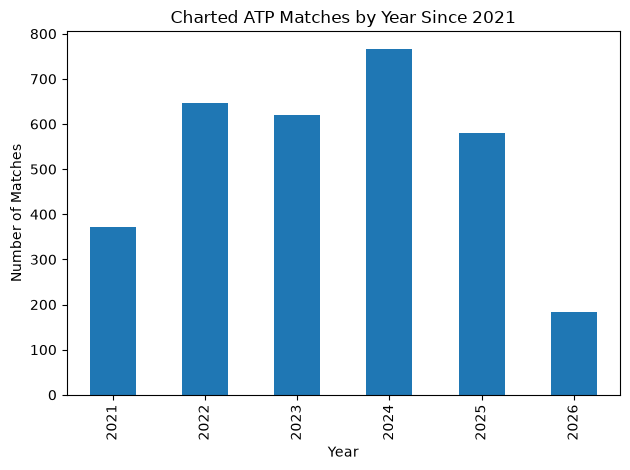

In [22]:
matches_by_year = matches_clean["Year"].value_counts().sort_index()

matches_by_year.plot(kind="bar")
plt.title("Charted ATP Matches by Year Since 2021")
plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.savefig("../reports/figures/matches_by_year.png")
plt.show()

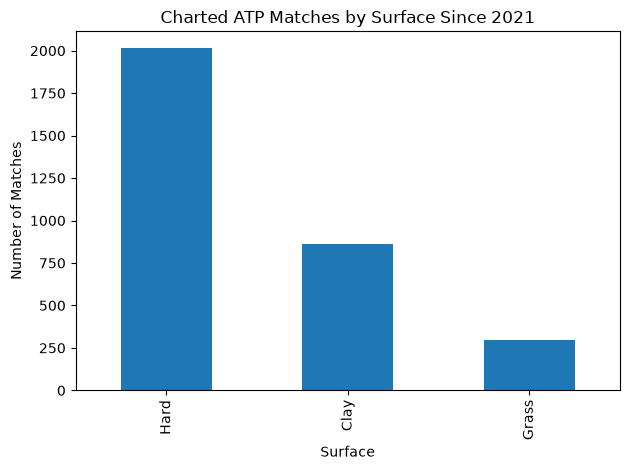

In [23]:
surface_counts = matches_clean["Surface"].value_counts()

surface_counts.plot(kind="bar")
plt.title("Charted ATP Matches by Surface Since 2021")
plt.xlabel("Surface")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.savefig("../reports/figures/matches_by_surface.png")
plt.show()

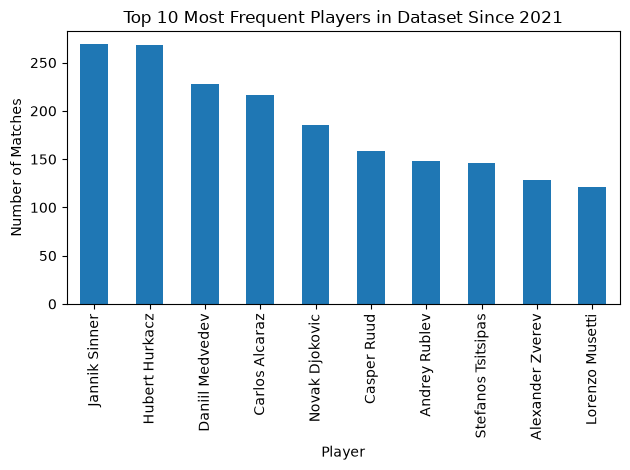

In [24]:
players = pd.concat([matches_clean["Player 1"], matches_clean["Player 2"]])

top_players = players.value_counts().head(10)

top_players.plot(kind="bar")
plt.title("Top 10 Most Frequent Players in Dataset Since 2021")
plt.xlabel("Player")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.savefig("../reports/figures/top_players.png")
plt.show()

In [25]:
def find_player_matches(player_name):
    mask = (
        matches_clean["Player 1"].str.contains(player_name, case=False, na=False) |
        matches_clean["Player 2"].str.contains(player_name, case=False, na=False)
    )
    
    return matches_clean[mask].sort_values("Date", ascending=False).head(10)

In [26]:
find_player_matches("Djokovic")

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Surface,Best of,Final TB?,Year
59,20260311-M-Indian_Wells_Masters-R16-Novak_Djok...,Novak Djokovic,Jack Draper,R,L,2026-03-11,Indian Wells Masters,R16,Hard,3,1,2026
65,20260309-M-Indian_Wells_Masters-R32-Aleksandar...,Aleksandar Kovacevic,Novak Djokovic,R,R,2026-03-09,Indian Wells Masters,R32,Hard,3,1,2026
123,20260201-M-Australian_Open-F-Novak_Djokovic-Ca...,Novak Djokovic,Carlos Alcaraz,R,R,2026-02-01,Australian Open,F,Hard,5,A,2026
125,20260130-M-Australian_Open-SF-Jannik_Sinner-No...,Jannik Sinner,Novak Djokovic,R,R,2026-01-30,Australian Open,SF,Hard,5,A,2026
127,20260128-M-Australian_Open-QF-Novak_Djokovic-L...,Novak Djokovic,Lorenzo Musetti,R,R,2026-01-28,Australian Open,QF,Hard,5,A,2026
136,20260124-M-Australian_Open-R32-Novak_Djokovic-...,Novak Djokovic,Botic Van De Zandschulp,R,R,2026-01-24,Australian Open,R32,Hard,5,A,2026
201,20251108-M-Athens-F-Novak_Djokovic-Lorenzo_Mus...,Novak Djokovic,Lorenzo Musetti,R,R,2025-11-08,Athens,F,Hard,3,1,2025
204,20251107-M-Athens-SF-Novak_Djokovic-Yannick_Ha...,Novak Djokovic,Yannick Hanfmann,R,R,2025-11-07,Athens,SF,Hard,3,1,2025
207,20251104-M-Athens-R16-Alejandro_Tabilo-Novak_D...,Alejandro Tabilo,Novak Djokovic,L,R,2025-11-04,Athens,R16,Hard,3,1,2025
248,20251011-M-Shanghai_Masters-SF-Valentin_Vacher...,Valentin Vacherot,Novak Djokovic,R,R,2025-10-11,Shanghai Masters,SF,Hard,3,1,2025


In [27]:
summary_table = pd.DataFrame({
    "Metric": [
        "Original dataset rows",
        "Filtered rows from 2021 onward",
        "Cleaned dataset rows",
        "Cleaned dataset columns",
        "Missing values after cleaning"
    ],
    "Value": [
        len(matches),
        len(matches_2021),
        len(matches_clean),
        matches_clean.shape[1],
        matches_clean.isnull().sum().sum()
    ]
})

summary_table

,Metric,Value
0,Original dataset rows,7566
1,Filtered rows from 2021 onward,3175
2,Cleaned dataset rows,3168
3,Cleaned dataset columns,12
4,Missing values after cleaning,0
